# Restaurant Customer Analysis

This project analyzes customer spending behavior using the Tips dataset.

The goal is to understand spending patterns across days, time periods and group sizes.

In [30]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [33]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [34]:
df.shape

(244, 7)

## Dataset

The dataset contains 244 observations and the following variables:

- total_bill : total bill amount
- tip : tip given
- day : day of the week
- time : lunch or dinner
- size : number of people

In [35]:
df["day"].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

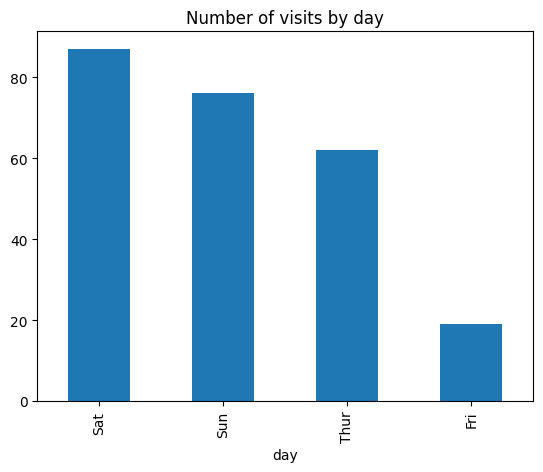

In [36]:
import matplotlib.pyplot as plt

df["day"].value_counts().plot(kind="bar")

plt.title("Number of visits by day")

plt.savefig("../images/visits_by_day.png")

plt.show()

In [37]:
df.groupby("day")["total_bill"].mean()

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

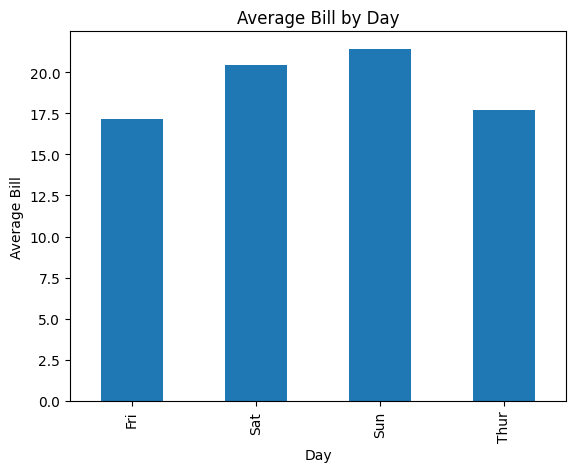

In [38]:

df.groupby("day")["total_bill"].mean().plot(kind="bar")

plt.title("Average Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Bill")

plt.savefig("../images/average_bill_by_day.png")

plt.show()

In [39]:
df.groupby("time")["total_bill"].mean()

time
Dinner    20.797159
Lunch     17.168676
Name: total_bill, dtype: float64

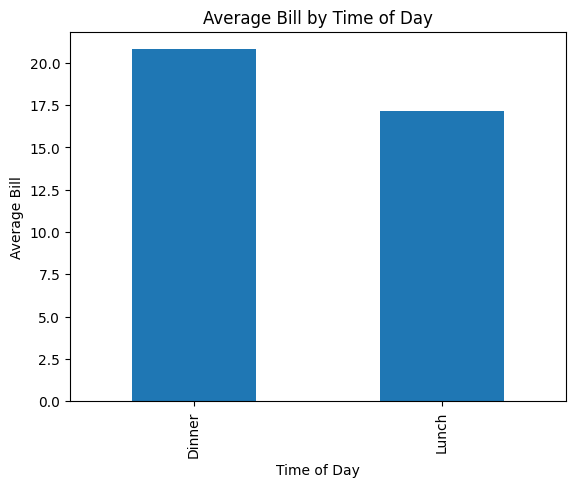

In [40]:
df.groupby("time")["total_bill"].mean().plot(kind="bar")

plt.title("Average Bill by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Bill")

plt.savefig("../images/average_bill_by_time.png")

plt.show()

In [41]:
df.groupby("size")["total_bill"].mean()

size
1     7.242500
2    16.448013
3    23.277632
4    28.613514
5    30.068000
6    34.830000
Name: total_bill, dtype: float64

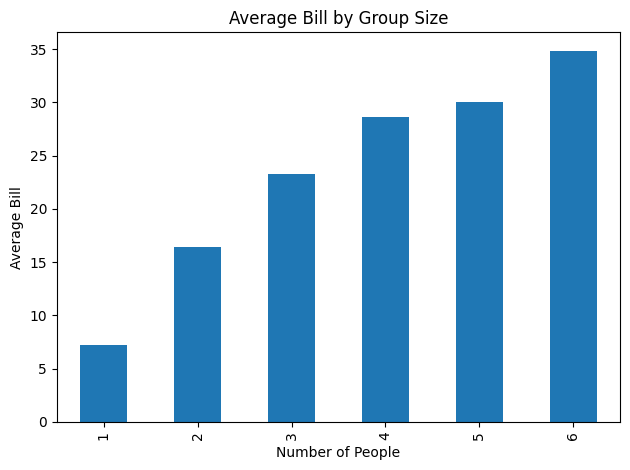

In [42]:
df.groupby("size")["total_bill"].mean().plot(kind="bar")

plt.title("Average Bill by Group Size")
plt.xlabel("Number of People")
plt.ylabel("Average Bill")

plt.tight_layout()

plt.savefig("../images/average_bill_by_group_size.png")

plt.show()

In [43]:
df.groupby("day")["total_bill"].sum()

day
Fri      325.88
Sat     1778.40
Sun     1627.16
Thur    1096.33
Name: total_bill, dtype: float64

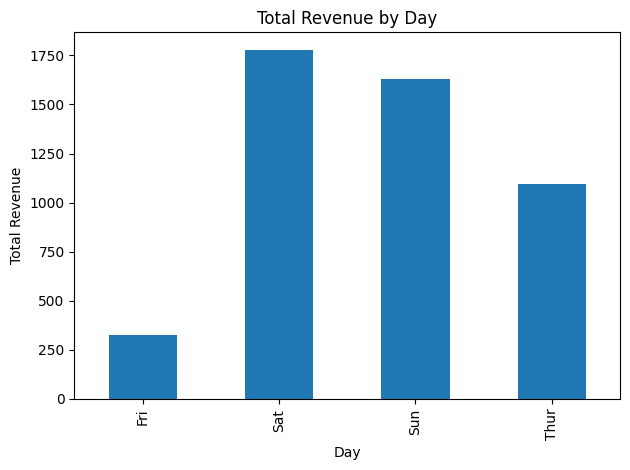

In [44]:
df.groupby("day")["total_bill"].sum().plot(kind="bar")

plt.title("Total Revenue by Day")
plt.xlabel("Day")
plt.ylabel("Total Revenue")

plt.tight_layout()

plt.savefig("../images/total_revenue_by_day.png")

plt.show()

In [45]:
df["tip_percentage"] = (df["tip"] / df["total_bill"]) * 100

df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [46]:
df["tip_percentage"].mean()

np.float64(16.08025817225047)

In [47]:
df["tip_percentage"] = (df["tip"] / df["total_bill"]) * 100

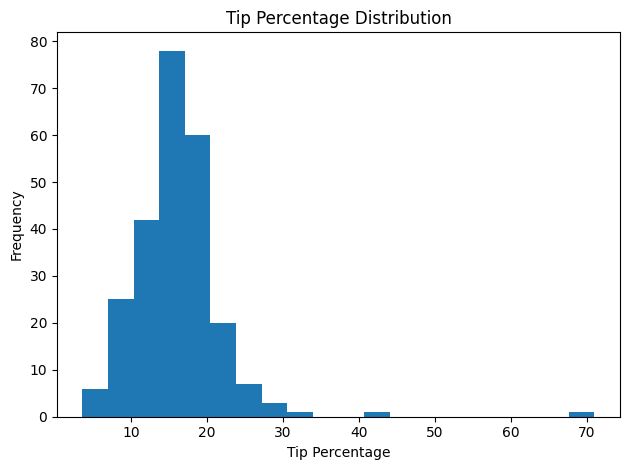

In [48]:
df["tip_percentage"].plot(kind="hist", bins=20)

plt.title("Tip Percentage Distribution")
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../images/tip_percentage_distribution.png")

plt.show()

In [49]:
df[["total_bill", "tip", "size"]].corr()

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [50]:
df.sort_values(by="total_bill", ascending=False).head(10)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
170,50.81,10.00,Male,Yes,Sat,Dinner,3,19.681165
212,48.33,9.00,Male,No,Sat,Dinner,4,18.621974
59,48.27,6.73,Male,No,Sat,Dinner,4,13.942407
156,48.17,5.00,Male,No,Sun,Dinner,6,10.379905
182,45.35,3.50,Male,Yes,Sun,Dinner,3,7.717751
102,44.30,2.50,Female,Yes,Sat,Dinner,3,5.643341
197,43.11,5.00,Female,Yes,Thur,Lunch,4,11.598237
142,41.19,5.00,Male,No,Thur,Lunch,5,12.138869
184,40.55,3.00,Male,Yes,Sun,Dinner,2,7.398274
95,40.17,4.73,Male,Yes,Fri,Dinner,4,11.774956


In [51]:
df.groupby("sex")["total_bill"].mean()

sex
Female    18.056897
Male      20.744076
Name: total_bill, dtype: float64

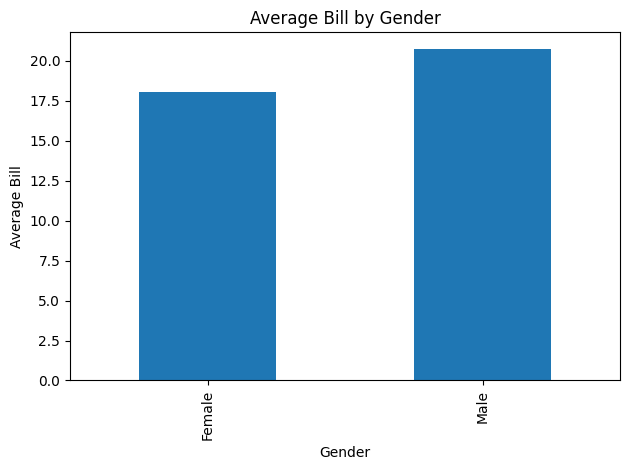

In [52]:
df.groupby("sex")["total_bill"].mean().plot(kind="bar")

plt.title("Average Bill by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Bill")

plt.tight_layout()

plt.savefig("../images/average_bill_by_gender.png")

plt.show()

In [53]:
df.groupby("smoker")["tip_percentage"].mean()

smoker
No     15.932846
Yes    16.319604
Name: tip_percentage, dtype: float64

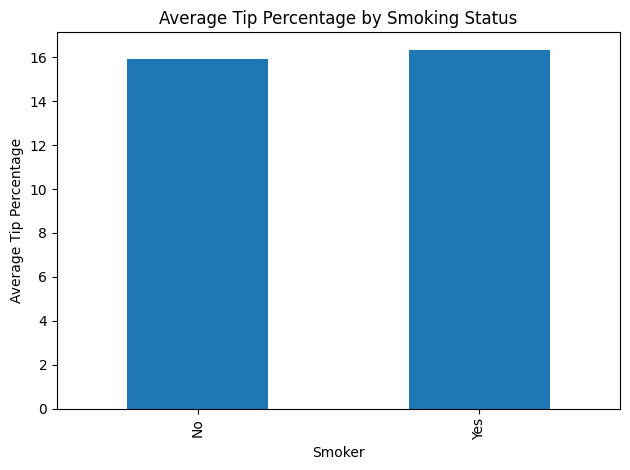

In [54]:
df.groupby("smoker")["tip_percentage"].mean().plot(kind="bar")

plt.title("Average Tip Percentage by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Average Tip Percentage")

plt.tight_layout()

plt.savefig("../images/tip_percentage_by_smoker.png")

plt.show()

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

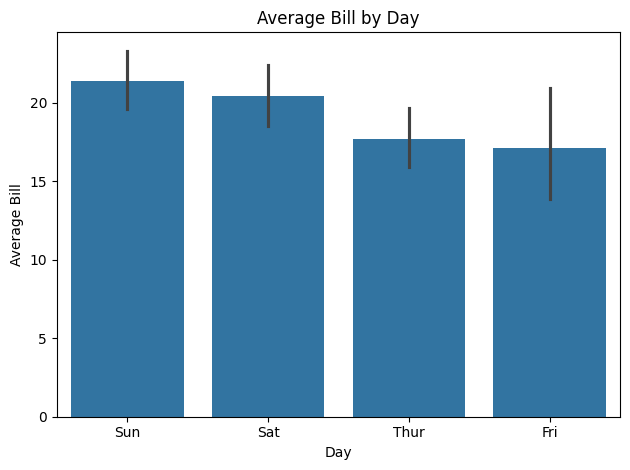

In [56]:
sns.barplot(data=df, x="day", y="total_bill")

plt.title("Average Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Bill")

plt.tight_layout()

plt.savefig("../images/seaborn_average_bill_by_day.png")

plt.show()

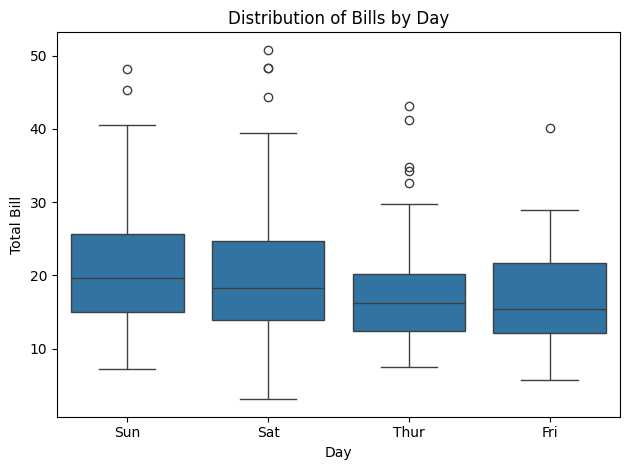

In [57]:
sns.boxplot(data=df, x="day", y="total_bill")

plt.title("Distribution of Bills by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")

plt.tight_layout()

plt.savefig("../images/bill_distribution_by_day.png")

plt.show()

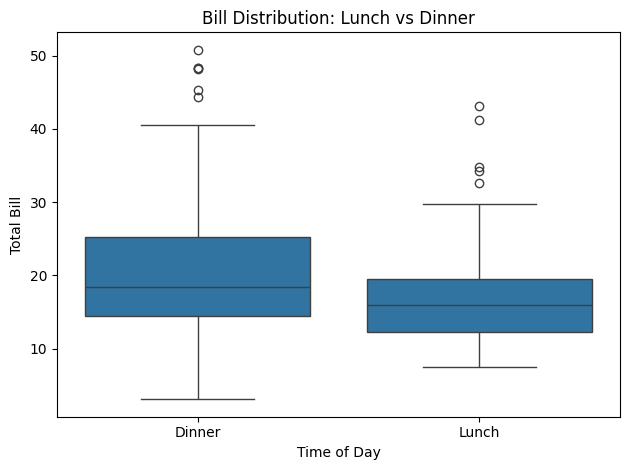

In [58]:
sns.boxplot(data=df, x="time", y="total_bill")

plt.title("Bill Distribution: Lunch vs Dinner")
plt.xlabel("Time of Day")
plt.ylabel("Total Bill")

plt.tight_layout()

plt.savefig("../images/bill_distribution_lunch_vs_dinner.png")

plt.show()

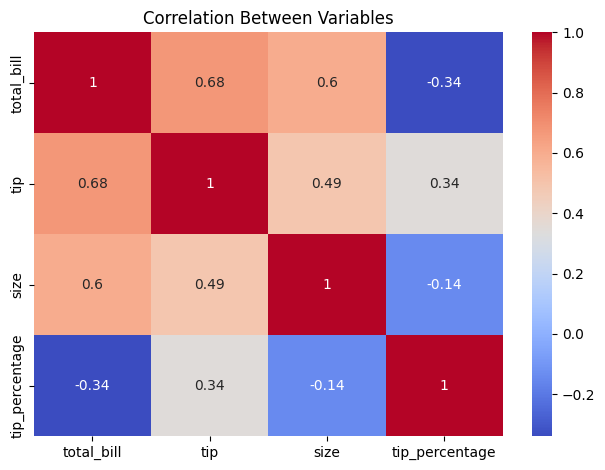

In [59]:
corr = df[["total_bill", "tip", "size", "tip_percentage"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Variables")

plt.tight_layout()

plt.savefig("../images/correlation_heatmap.png")

plt.show()

In [60]:
total_revenue = df["total_bill"].sum()
average_bill = df["total_bill"].mean()
average_tip_percentage = df["tip_percentage"].mean()
total_customers = df.shape[0]

print("Total Revenue:", round(total_revenue, 2))
print("Average Bill:", round(average_bill, 2))
print("Average Tip Percentage:", round(average_tip_percentage, 2))
print("Total Customers:", total_customers)

Total Revenue: 4827.77
Average Bill: 19.79
Average Tip Percentage: 16.08
Total Customers: 244


In [61]:
df.groupby("day").agg({
    "total_bill": ["sum", "mean"],
    "tip": "mean"
})

total_bill                  tip
            sum       mean      mean
day                                 
Fri      325.88  17.151579  2.734737
Sat     1778.40  20.441379  2.993103
Sun     1627.16  21.410000  3.255132
Thur    1096.33  17.682742  2.771452

In [62]:
df.groupby("time").agg({
    "total_bill": ["sum", "mean"],
    "tip": "mean"
})

total_bill                  tip
              sum       mean      mean
time                                  
Dinner    3660.30  20.797159  3.102670
Lunch     1167.47  17.168676  2.728088

## Business Insights

- Weekend generates the highest revenue
- Dinner is more profitable than lunch
- Larger groups significantly increase the total bill
- Tip percentage remains relatively stable around 16%

## Key Insights

- Saturday has the highest number of visits.
- Sunday has the highest average bill.
- Dinner generates higher bills than lunch.
- Larger groups tend to increase the total bill.
- Tip percentages usually range between 10% and 20%.
- Smoking status has little impact on tipping behavior.